# 04 Stability, Sensitivity and Stress Testing

**Author:** Rowan Walker

This notebook captures stability, sensitivity and stress testing. Various tests have been designed to investigate robustness of model architecture on back testing performance.

### 4.1 Imports

Note: No seed has been set as this notebook will include seed stability testing

In [2]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.mplot3d import Axes3D

from src.data.preprocess import generate_valid_tickers, generate_model_inputs
from src.inference.inference import model_inference
from src.training.train import train_model
from src.utils.backtest import backtest, optimise_sharpe
from src.utils.seed import set_global_seed

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch")
warnings.filterwarnings("ignore", category=FutureWarning, module="torch")
warnings.filterwarnings("ignore", category=UserWarning, module="hmmlearn")

%reload_ext autoreload
%autoreload 2

#### Setting a common parameter grid for the back test

In [3]:
param_grid = {
    'long_threshold': 0.6, 
    'short_threshold': 0.4, 
    'target_vol': 0.2,  
    'slippage': 1.0,
    'commission': 1.0,
    'take_profit': 0.16,
    'stop_loss': -0.02,
    'max_hold_days': 18.0,
    'max_drawdown': 0.2,
    'leverage': 2.0}

#### Defining an E2E model run

In [4]:
def e2e(param_grid, noise=False, noise_level=None):
    for i, t in enumerate((1, 5, 21)):
        valid_tickers = generate_valid_tickers(
            start_date='2010-12-01',
            end_date='2025-12-01')
        
        X, y, stock_ids, regime_X, full_df = generate_model_inputs(
            tickers=valid_tickers,
            train_start='2010-12-01',
            train_end='2019-12-01',
            hold_days=t,
            verbose=False
        )

        if noise:
            X = inject_noise(X, noise_level)

        train_model(
            X, 
            y, 
            stock_ids, 
            regime_X, 
            hold_days=t,
            verbose=False
        )

    model_inference(
        valid_tickers, 
        full_df, 
        feature_dim=X.shape[2], 
        hold_days=(1,5,21),
        verbose=False
    )
    
    sharpe = backtest(param_grid, start_date='2020-01-01', end_date='2025-12-31', sharpe_only=True)

    return sharpe

## 4.2 Stability and Sensitivity Testing

### 4.2.1 Test 1: Seed stability

In [164]:
# Fixed seed set for stability analysis
seeds = (
    153902345, 98234123, 492384923, 239482394, 832947234,
    674839201, 120394857, 908172345, 561238947, 734892015
)

results = {}

for seed in seeds:
    set_global_seed(seed)
    sharpe = e2e(param_grid)
    results[seed] = round(sharpe, 2)
    
df = pd.DataFrame.from_dict(results, orient='index', columns=['sharpe'])

pd.DataFrame({
    "Mean Sharpe": [df["sharpe"].mean()],
    "Std": [df["sharpe"].std()],
    "Min": [df["sharpe"].min()],
    "Max": [df["sharpe"].max()],
    "Stability": [df["sharpe"].mean() / df["sharpe"].std()]
}, index=['Baseline']).round(2)

,Mean Sharpe,Std,Min,Max,Stability
Baseline,3.4,0.45,2.59,3.9,7.51


**Conclusion**: Model performance on out-of-sample back test is robust to changes in random seed i.e. model is broadly seed-invariant; stability index of 7.51 further indicates this. Performance remained robust throughout.

### Test 2: Transaction Cost sensitivity

In [129]:
# Return to default seed
set_global_seed()

slippage_grid = np.arange(0, 21, 2)
commission_grid = np.arange(0, 21, 2)

results = pd.DataFrame(index=slippage_grid, columns=commission_grid, dtype=float)

for s in slippage_grid:
    param_grid['slippage'] = s
    for c in commission_grid:
        param_grid['commission'] = c
        sharpe = backtest(
            param_grid=param_grid,
            start_date='2020-01-01',
            end_date='2025-12-31',
            sharpe_only=True
        )
        results.loc[s, c] = sharpe

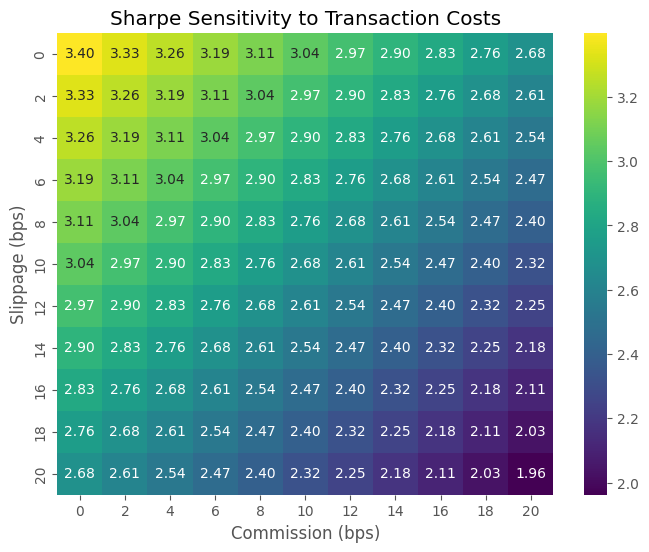

In [130]:
plt.figure(figsize=(8, 6))
sns.heatmap(results, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Commission (bps)")
plt.ylabel("Slippage (bps)")
plt.title("Sharpe Sensitivity to Transaction Costs")
plt.show()

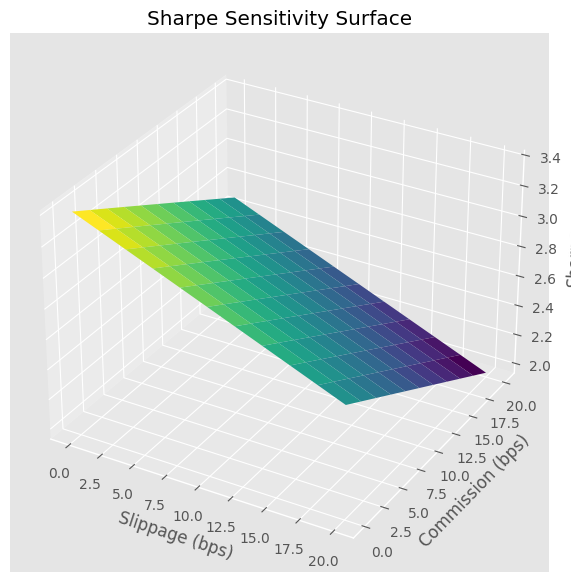

In [131]:
S, C = np.meshgrid(slippage_grid, commission_grid, indexing='ij')
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S, C, results.values, cmap='viridis')
ax.set_xlabel('Slippage (bps)')
ax.set_ylabel('Commission (bps)')
ax.set_zlabel('Sharpe')
ax.set_title('Sharpe Sensitivity Surface')
plt.show()

**Conclusion**: The above set of results makes sense when it is considered that the overall trading cost is a simple sum of slippage and commission. Model performance, indicated by out-of-sample back test Sharpe ratio remains robust from 0bps all the way up to 40bps which would be generally considered high in terms of the liquid, large-cap equities being traded in this model. Hence, the model remains robust to trading cost fluctuations.

### Test 3: Volatility targeting and leverage sensitivity

In [126]:
# Return to default seed
set_global_seed()

# Reset base param grid
param_grid = {
    'long_threshold': 0.6, 
    'short_threshold': 0.4, 
    'target_vol': 0.2,  
    'slippage': 1.0,
    'commission': 1.0,
    'take_profit': 0.16,
    'stop_loss': -0.02,
    'max_hold_days': 18.0,
    'max_drawdown': 0.2,
    'leverage': 2.0}

target_vol_grid = np.arange(0.05, 0.35, 0.05)
leverage_grid = np.arange(1.0, 11.0, 1)

results = pd.DataFrame(dtype=float)

for v in target_vol_grid:
    v = round(v, 2)
    param_grid['target_vol'] = v
    for l in leverage_grid:
        param_grid['leverage'] = l
        sharpe = backtest(
            param_grid=param_grid,
            start_date='2020-01-01',
            end_date='2025-12-31',
            sharpe_only=True
        )
        results.loc[v, l] = sharpe

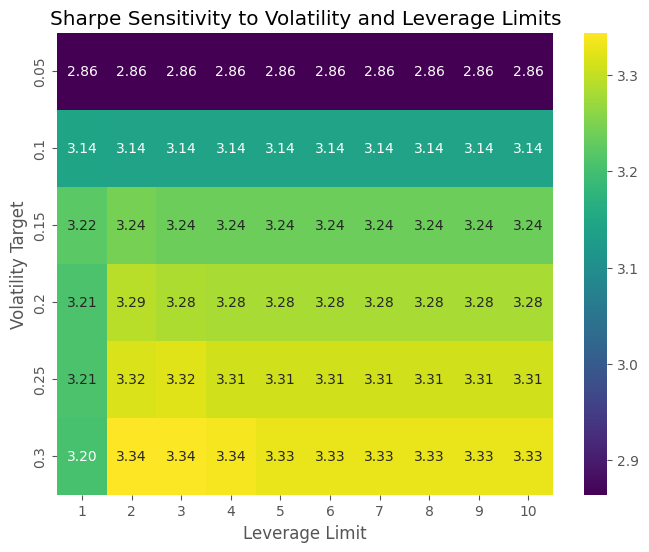

In [127]:
plt.figure(figsize=(8, 6))
sns.heatmap(results, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Leverage Limit")
plt.ylabel("Volatility Target")
plt.title("Sharpe Sensitivity to Volatility and Leverage Limits")
plt.show()

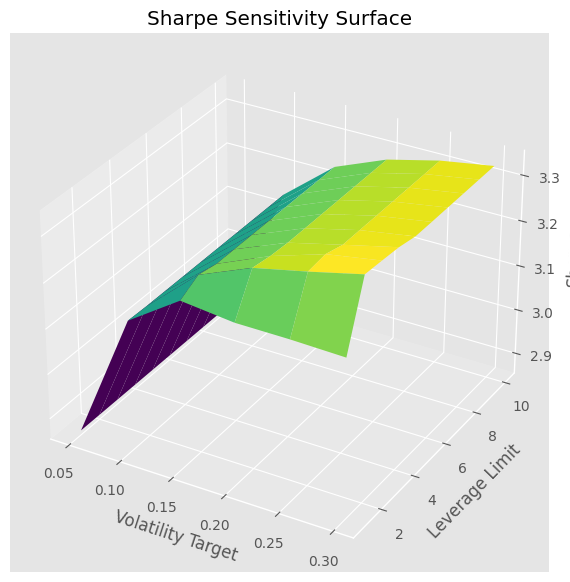

In [128]:
V, L = np.meshgrid(vol_target_grid, leverage_grid, indexing='ij')
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(V, L, results.values, cmap='viridis')
ax.set_xlabel('Volatility Target')
ax.set_ylabel('Leverage Limit')
ax.set_zlabel('Sharpe')
ax.set_title('Sharpe Sensitivity Surface')
plt.show()

**Conclusion**: Above results are more interesting; high volatility limits are the limiting factor and Sharpe is not further increased by additional leverage. This is perhaps a construct of the volatility targeting in the portfolio already maxing out the allowed volatility level and leverage is thus constrained. As expected, Sharpe increases linearly with volatility target, in-line with expectations.

### Test 4: Signal Threshold sensitivity

In [108]:
# Return to default seed
set_global_seed()

# Reset base param grid
param_grid = {
    'long_threshold': 0.6, 
    'short_threshold': 0.4, 
    'target_vol': 0.2,  
    'slippage': 1.0,
    'commission': 1.0,
    'take_profit': 0.16,
    'stop_loss': -0.02,
    'max_hold_days': 18.0,
    'max_drawdown': 0.2,
    'leverage': 2.0}

long_threshold_grid = np.arange(0.55, 1, 0.05)
short_threshold_grid = np.arange(0.05, 0.5, 0.05)

results = pd.DataFrame(dtype=float)

for l in long_threshold_grid:
    l = round(l, 2)
    param_grid['long_threshold'] = l
    for s in short_threshold_grid:
        s = round(s, 2)
        param_grid['short_threshold'] = s
        sharpe = backtest(
            param_grid=param_grid,
            start_date='2020-01-01',
            end_date='2025-12-31',
            sharpe_only=True
        )
        results.loc[l, s] = sharpe

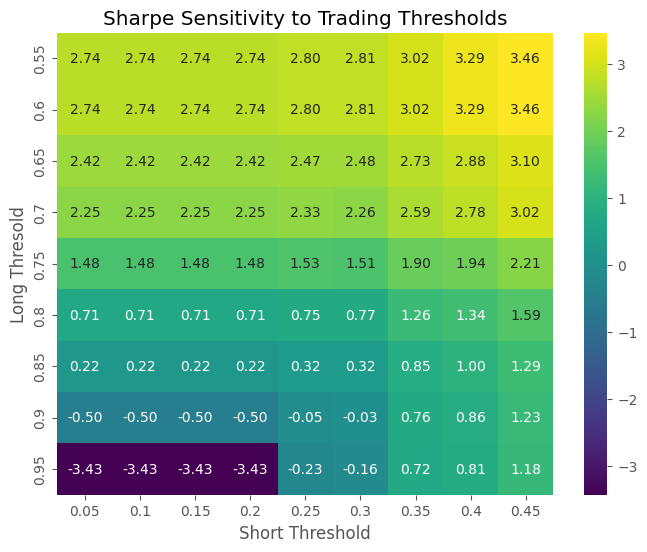

In [110]:
plt.figure(figsize=(8, 6))
sns.heatmap(results, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Short Threshold")
plt.ylabel("Long Thresold")
plt.title("Sharpe Sensitivity to Trading Thresholds")
plt.show()

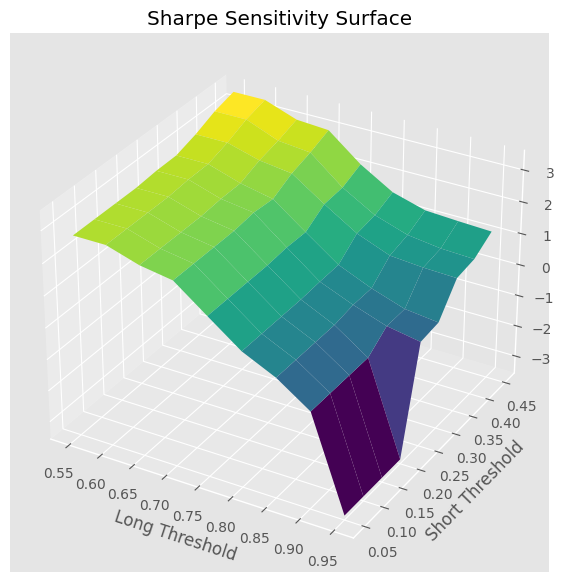

In [111]:
L, D = np.meshgrid(long_threshold_grid, short_threshold_grid, indexing='ij')
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(L, D, results.values, cmap='viridis')
ax.set_xlabel('Long Threshold')
ax.set_ylabel('Short Threshold')
ax.set_zlabel('Sharpe')
ax.set_title('Sharpe Sensitivity Surface')
plt.show()

**Conclusion**: Results are again interesting as it is clear that the model is more sensitive to changes in the short-threshold. This is understandable when considering that short-signals are generated at <50% the rate of long-signals, therefore decreasing the short threshold means the model is becoming closer to a long-only strategy. This perhaps indicates the short-signal is not adding much value, indeed when the short threshold is 0.05 i.e. virtually no short signals the model still performs well as long as the long threshold is not too high. This requires more investigation.

### Test 5: Label shuffling

In [163]:
from src.common.config import get_config_path
from src.data.config import load_data_config
from src.utils.backtest import add_signal

# Load YAML files
data_cfg = load_data_config(get_config_path("data.yaml"))

set_global_seed()

param_grid = {
    'long_threshold': 0.6, 
    'short_threshold': 0.4, 
    'target_vol': 0.2,  
    'slippage': 1.0,
    'commission': 1.0,
    'take_profit': 0.16,
    'stop_loss': -0.02,
    'max_hold_days': 18.0,
    'max_drawdown': 0.2,
    'leverage': 2.0}

file_loc = data_cfg['paths']['inference']
file_name = 'inference.parquet'
inference = pd.read_parquet(file_loc / file_name)

inference_shuffle = add_signal(
    param_grid['long_threshold'], 
    param_grid['short_threshold'],
    df=inference).copy()

inference_shuffle['Position'] = np.random.permutation(inference_shuffle['Position'])

inference['Position'], inference_shuffle['Position']

results = {}

for test, df in zip(('signal', 'shuffled signal'), (inference, inference_shuffle)):
    sharpe = backtest(
        param_grid=param_grid,
        start_date='2020-01-01',
        end_date='2025-12-31',
        df=df,
        sharpe_only=True
    )
    
    results[test] = round(sharpe, 2)

pd.DataFrame(results, index=['Sharpe']).T

,Sharpe
signal,3.29
shuffled signal,4.42


**Conclusion**: The author acknowledges that in it's current state, the model is simply not predictive as shown by the shuffled signal out-performing the non-shuffled signal. This is for numerous reasons: firstly, the device the model is trained on (personal Macbooke) has vastly insufficient compute to train a model with enough complexity to capture any reliable signal; primarily due to highly noisy equity markets. Any transformer trained on liquid equity markets will struggle to pick up any reasonable signal unless vast quantities of data are ingested. The author plans to train the model using rented GPU compute, however the current model serves to act as a framework to show the logic and eventual pitfalls of using sophisticated ML models for return prediction. Further investigations are ongoing as to how the Sharpe ratio is high despite this, please see notebook 06 for an investigation into leakage and look-ahead bias and the author will further review and re-factor the back test logic.

### Test 6: Stress Testing - Noise injection

#### Define a function which allows for noise injection

In [5]:
def inject_noise(X, noise_level):
    noise = noise_level * np.random.randn(*X.shape)
    return X + noise

In [6]:
# Return to default seed
set_global_seed()

# Reset base param grid
param_grid = {
    'long_threshold': 0.6, 
    'short_threshold': 0.4, 
    'target_vol': 0.2,  
    'slippage': 1.0,
    'commission': 1.0,
    'take_profit': 0.16,
    'stop_loss': -0.02,
    'max_hold_days': 18.0,
    'max_drawdown': 0.2,
    'leverage': 2.0}

results = {}

for n in (0, 0.01, 0.02, 0.05, 0.1, 0.25):
    sharpe = e2e(param_grid, noise=True, noise_level=n)
    results[n] = round(sharpe, 2)
    
df = pd.DataFrame.from_dict(results, orient='index', columns=['sharpe'])
df.index.name = 'Noise level'
df

,sharpe
Noise level,
0.00,3.58
0.01,2.83
0.02,3.45
0.05,3.16
0.10,3.26
0.25,3.66


**Conclusion**: The model demonstrates strong robustness to feature perturbations. While Sharpe declines modestly at very low noise (0.01), performance stabilises and even improves as noise increases, remaining within the same Sharpe regime across all tested levels. The strategy does not collapse under noise, suggesting it has learned structural, generalisable relationships rather than overfitting. Higher noise appears to act as a regulariser, slightly improving out-of-sample Sharpe. This indicates the model’s predictive signal is stable and robust to real-world data imperfections, a key requirement for quantitative trading systems.